In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# ===============================
# Excel-Daten einlesen
# ===============================
df = pd.read_excel('Exp2-3 Claire.xlsx', engine="openpyxl",
                   usecols="A,F,G,J", skiprows=6, nrows=9)

df.columns = ["x_A", "p_A", "p_B", "p_ges"]
x = df["x_A"]
pA = df["p_A"]
pB = df["p_B"]
p_ges = df["p_ges"]
R = 8.314  # J/mol/K
T = 298.15  # K

# ===============================import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# ===============================
# Excel-Daten einlesen
# ===============================
df = pd.read_excel('Exp2-3 Claire.xlsx', engine="openpyxl",
                   usecols="A,J", skiprows=6, nrows=9)

df.columns = ["x_A", "p_ges"]
x = df["x_A"]
p_ges = df["p_ges"]

R = 8.314  # J/mol/K
T = 298.15  # K

# ===============================
# Fitfunktion definieren
# ===============================
def fit_pges(x_data, Omega):
    return p_ges.iloc[0] * (1 - x_data) * np.exp(Omega / (R * T) * x_data**2) + \
           p_ges.iloc[-1] * x_data * np.exp(Omega / (R * T) * (1 - x_data)**2)

# ===============================
# Fit ausführen
# ===============================
initial_guess = [100]

try:
    params, cov = curve_fit(fit_pges, x, p_ges, p0=initial_guess)
    Omega = params[0]
    Omega_err = np.sqrt(cov[0, 0])

    print(f"Gefittetes Ω: {Omega:.2f} ± {Omega_err:.2f} J/mol")

    # Fitkurve zeichnen
    x_fit = np.linspace(0, 1, 200)
    p_fit = fit_pges(x_fit, Omega)

    # ===============================
    # Plot
    # ===============================
    plt.figure(figsize=(8, 6))
    plt.plot(x, p_ges, 'ro', label="Messwerte p_ges")
    plt.plot(x_fit, p_fit, 'b-', label="Fit p_ges (Ω)")
    plt.xlabel(r"Molenbruch $x_A$")
    plt.ylabel("Dampfdruck / mbar")
    plt.title("Fit des Gesamtdampfdrucks")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except RuntimeError as e:
    print(f"Fit konnte nicht durchgeführt werden: {e}")
except ValueError as e:
    print(f"Wertfehler: {e}")
# Plot vorbereiten
# ===============================
fig, ax1 = plt.subplots()

# Gemessener Gesamtdampfdruck
ax1.plot(x, p_ges, marker="o", linestyle="", color="red", label="p_ges Messwerte")

# Idealer Dampfdruck (Verbindungslinien)
ax1.plot([x[0], x[8]], [p_ges[0], p_ges[8]], color="gray", linestyle="--")
ax1.plot([0, x[8]], [0, p_ges[8]], color="gray", linestyle="--")
ax1.plot([1, x[0]], [1, p_ges[0]], color="gray", linestyle="--")

# Achsen
ax1.set_xlabel(r"Molenbruch $x_A$")
ax1.set_ylabel("Dampfdruck / mbar")
ax2 = ax1.twinx()
ax2.set_ylabel("Dampfdruck / mbar")
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 200)
ax2.set_ylim(ax1.get_ylim())
ax1.set_xticks(x)

# ===============================
# Fitfunktion definieren
# ===============================
def fit_pges(x_data, Omega):
    return p_ges[0] * (1 - x_data) * np.exp(Omega / (R * T) * x_data**2) + \
           p_ges[8] * x_data * np.exp(Omega / (R * T) * (1 - x_data)**2)

initial_guess = [100]

try:
    # Fit ausführen mit Fehlerabschätzung
    params, params_covariance = curve_fit(fit_pges, x, p_ges, p0=initial_guess)
    Omega = params[0]
    Omega_err = np.sqrt(params_covariance[0, 0])

    print(f"Gefittetes Ω: {Omega:.2f} ± {Omega_err:.2f} J/mol")

    # Fit-Kurve berechnen
    x_fit = np.linspace(0, 1, 100)
    p_fit = fit_pges(x_fit, Omega)
    ax1.plot(x_fit, p_fit, color="blue", label="p_ges Fit")

    # Partialdrucke berechnen
    p_A_smooth = p_ges[0] * (1 - x_fit) * np.exp(Omega / (R * T) * x_fit**2)
    p_B_smooth = p_ges[8] * x_fit * np.exp(Omega / (R * T) * (1 - x_fit)**2)

    ax1.plot(x_fit, p_A_smooth, color="green", linestyle="-", label="p_A (theor.)")
    ax1.plot(x_fit, p_B_smooth, color="purple", linestyle="-", label="p_B (theor.)")

    # Tabelle mit Werten bei original x-Werten
    p_A_orig = p_ges[0] * (1 - x) * np.exp(Omega / (R * T) * x**2)
    p_B_orig = p_ges[8] * x * np.exp(Omega / (R * T) * (1 - x)**2)

    partial_pressure_df = pd.DataFrame({
        'x_A': x,
        'p_A (berechnet)': p_A_orig,
        'p_B (berechnet)': p_B_orig
    })
    print(partial_pressure_df)

except RuntimeError as e:
    print(f"Fehler beim Fit: {e}")
except ValueError as e:
    print(f"Wertfehler: {e}")

# Legende und Anzeige
ax1.legend()
plt.tight_layout()
plt.show()

TypeError: unsupported operand type(s) for -: 'int' and 'str'

In [2]:
print(df.head(9))

     x_A  p_A  p_B  p_ges
0      0  NaN  NaN   77.3
1  0.057  NaN  NaN  116.0
2  0.133  NaN  NaN  105.2
3   0.24  NaN  NaN   97.5
4    0.4  NaN  NaN  104.8
5  0.667  NaN  NaN   99.7
6    1.2  NaN  NaN   93.3
7    2.8  NaN  NaN  102.2
8      /  NaN  NaN   75.3


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# ===============================
# Excel-Daten einlesen
# ===============================
df = pd.read_excel('Exp2-3 Claire.xlsx', engine="openpyxl",
                   usecols="A,J", skiprows=6, nrows=9)

df.columns = ["x_A", "p_ges"]
x = df["x_A"]
p_ges = df["p_ges"]

R = 8.314  # J/mol/K
T = 298.15  # K

# ===============================
# Fitfunktion definieren
# ===============================
def fit_pges(x_data, Omega):
    return p_ges.iloc[0] * (1 - x_data) * np.exp(Omega / (R * T) * x_data**2) + \
           p_ges.iloc[-1] * x_data * np.exp(Omega / (R * T) * (1 - x_data)**2)

# ===============================
# Fit ausführen
# ===============================
initial_guess = [100]

try:
    params, cov = curve_fit(fit_pges, x, p_ges, p0=initial_guess)
    Omega = params[0]
    Omega_err = np.sqrt(cov[0, 0])

    print(f"Gefittetes Ω: {Omega:.2f} ± {Omega_err:.2f} J/mol")

    # Fitkurve zeichnen
    x_fit = np.linspace(0, 1, 200)
    p_fit = fit_pges(x_fit, Omega)

    # ===============================
    # Plot
    # ===============================
    plt.figure(figsize=(8, 6))
    plt.plot(x, p_ges, 'ro', label="Messwerte p_ges")
    plt.plot(x_fit, p_fit, 'b-', label="Fit p_ges (Ω)")
    plt.xlabel(r"Molenbruch $x_A$")
    plt.ylabel("Dampfdruck / mbar")
    plt.title("Fit des Gesamtdampfdrucks")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except RuntimeError as e:
    print(f"Fit konnte nicht durchgeführt werden: {e}")
except ValueError as e:
    print(f"Wertfehler: {e}")

TypeError: unsupported operand type(s) for -: 'int' and 'str'

Gefittetes Ω: 3309.64 ± 343.98 J/mol


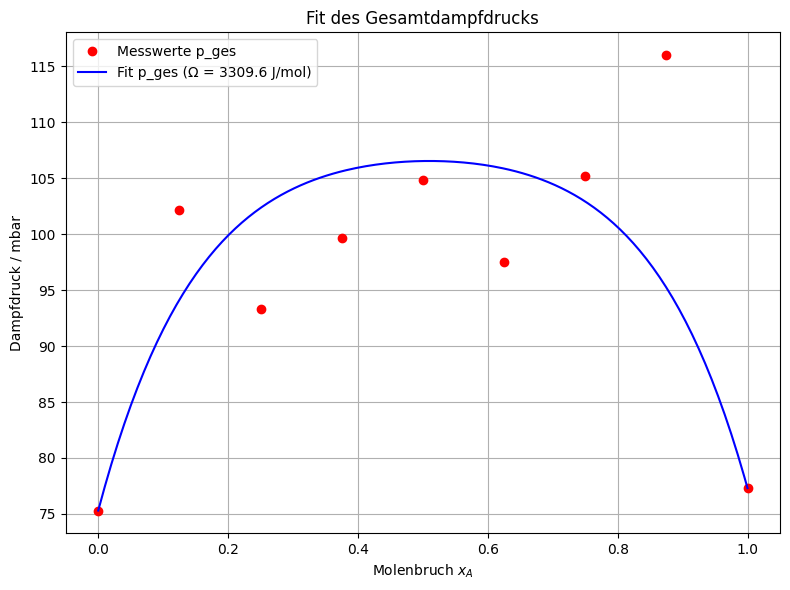

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# ===============================
# Excel-Daten einlesen und bereinigen
# ===============================
df = pd.read_excel('Exp2-3_Claire.xlsx', engine="openpyxl",
                   usecols="A,J", skiprows=6, nrows=9)

df.columns = ["x_A", "p_ges"]

# In numerisch umwandeln und fehlerhafte Zeilen entfernen
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

x = df["x_A"].values
p_ges = df["p_ges"].values

# ===============================
# Konstanten
# ===============================
R = 8.314  # J/mol/K
T = 298.15  # K

# ===============================
# Fitfunktion definieren
# ===============================
def fit_pges(x_data, Omega):
    return p_ges[0] * (1 - x_data) * np.exp(Omega / (R * T) * x_data**2) + \
           p_ges[-1] * x_data * np.exp(Omega / (R * T) * (1 - x_data)**2)

# ===============================
# Fit ausführen
# ===============================
initial_guess = [100]

try:
    params, cov = curve_fit(fit_pges, x, p_ges, p0=initial_guess)
    Omega = params[0]
    Omega_err = np.sqrt(cov[0, 0])

    print(f"Gefittetes Ω: {Omega:.2f} ± {Omega_err:.2f} J/mol")

    # ===============================
    # Plot
    # ===============================
    x_fit = np.linspace(0, 1, 200)
    p_fit = fit_pges(x_fit, Omega)

    plt.figure(figsize=(8, 6))
    plt.plot(x, p_ges, 'ro', label="Messwerte p_ges")
    plt.plot(x_fit, p_fit, 'b-', label=f"Fit p_ges (Ω = {Omega:.1f} J/mol)")
    plt.xlabel(r"Molenbruch $x_A$")
    plt.ylabel("Dampfdruck / mbar")
    plt.title("Fit des Gesamtdampfdrucks")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except RuntimeError as e:
    print(f"Fit konnte nicht durchgeführt werden: {e}")
except ValueError as e:
    print(f"Wertfehler: {e}")

Gefittetes Ω: 3309.64 ± 343.98 J/mol
     x_A  p_A (berechnet)  p_B (berechnet)
0  0.000        75.300000         0.000000
1  0.125        67.276484        26.856044
2  0.250        61.389948        40.953282
3  0.375        56.782864        48.833422
4  0.500        52.568922        53.965175
5  0.625        47.569944        58.291041
6  0.750        39.893689        63.020491
7  0.875        26.161192        69.063376
8  1.000         0.000000        77.300000

Fitparameter & Statistik:
Parameter                 Wert
----------------------------------------
Omega (J/mol)             3309.64
Fehler von Omega          343.98
R-squared                 0.5046
Adj. R-squared            0.4338
Reduced Chi²              86.4529


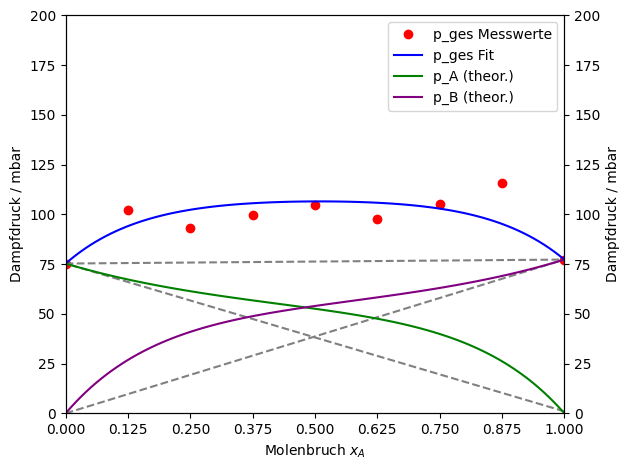

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# ===============================
# Excel-Daten einlesen
# ===============================
df = pd.read_excel('Exp2-3_Claire.xlsx', engine="openpyxl",
                   usecols="A,F,G,J", skiprows=6, nrows=9)

df.columns = ["x_A", "p_A", "p_B", "p_ges"]
x = df["x_A"]
pA = df["p_A"]
pB = df["p_B"]
p_ges = df["p_ges"]
R = 8.314  # J/mol/K
T = 298.15  # K

# ===============================
# Plot vorbereiten
# ===============================
fig, ax1 = plt.subplots()

# Gemessener Gesamtdampfdruck
ax1.plot(x, p_ges, marker="o", linestyle="", color="red", label="p_ges Messwerte")

# Idealer Dampfdruck (Verbindungslinien)
ax1.plot([x[0], x[8]], [p_ges[0], p_ges[8]], color="gray", linestyle="--")
ax1.plot([0, x[8]], [0, p_ges[8]], color="gray", linestyle="--")
ax1.plot([1, x[0]], [1, p_ges[0]], color="gray", linestyle="--")

# Achsen
ax1.set_xlabel(r"Molenbruch $x_A$")
ax1.set_ylabel("Dampfdruck / mbar")
ax2 = ax1.twinx()
ax2.set_ylabel("Dampfdruck / mbar")
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 200)
ax2.set_ylim(ax1.get_ylim())
ax1.set_xticks(x)

# ===============================
# Fitfunktion definieren
# ===============================
def fit_pges(x_data, Omega):
    return p_ges[0] * (1 - x_data) * np.exp(Omega / (R * T) * x_data**2) + \
           p_ges[8] * x_data * np.exp(Omega / (R * T) * (1 - x_data)**2)

initial_guess = [100]

try:
    # Fit ausführen mit Fehlerabschätzung
    params, params_covariance = curve_fit(fit_pges, x, p_ges, p0=initial_guess)
    Omega = params[0]
    Omega_err = np.sqrt(params_covariance[0, 0])

    print(f"Gefittetes Ω: {Omega:.2f} ± {Omega_err:.2f} J/mol")

    # Fit-Kurve berechnen
    x_fit = np.linspace(0, 1, 100)
    p_fit = fit_pges(x_fit, Omega)
    ax1.plot(x_fit, p_fit, color="blue", label="p_ges Fit")

    # Partialdrucke berechnen
    p_A_smooth = p_ges[0] * (1 - x_fit) * np.exp(Omega / (R * T) * x_fit**2)
    p_B_smooth = p_ges[8] * x_fit * np.exp(Omega / (R * T) * (1 - x_fit)**2)

    ax1.plot(x_fit, p_A_smooth, color="green", linestyle="-", label="p_A (theor.)")
    ax1.plot(x_fit, p_B_smooth, color="purple", linestyle="-", label="p_B (theor.)")

    # Tabelle mit Werten bei original x-Werten
    p_A_orig = p_ges[0] * (1 - x) * np.exp(Omega / (R * T) * x**2)
    p_B_orig = p_ges[8] * x * np.exp(Omega / (R * T) * (1 - x)**2)

    partial_pressure_df = pd.DataFrame({
        'x_A': x,
        'p_A (berechnet)': p_A_orig,
        'p_B (berechnet)': p_B_orig
    })
    print(partial_pressure_df)

except RuntimeError as e:
    print(f"Fehler beim Fit: {e}")
except ValueError as e:
    print(f"Wertfehler: {e}")

# ===============================
# Statistische Auswertung des Fits
# ===============================

# Refit mit Ausgabe der Kovarianzmatrix (für Fehlerabschätzung)
params, params_covariance = curve_fit(fit_pges, x, p_ges, p0=[100])
Omega = params[0]
Omega_err = np.sqrt(params_covariance[0, 0])

# Fit-Werte und Residuen
p_fit_data = fit_pges(x, Omega)
residuals = p_ges - p_fit_data

# R²
ss_res = np.sum(residuals**2)
ss_tot = np.sum((p_ges - np.mean(p_ges))**2)
r_squared = 1 - (ss_res / ss_tot)

# Adjustiertes R²
n = len(p_ges)         # Anzahl Datenpunkte
p = len(params)        # Anzahl Parameter (hier 1)
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

# Reduced Chi-Square
reduced_chi_sq = ss_res / (n - p)

# ===============================
# Ergebnisse als "Tabelle" in der Konsole ausgeben
# ===============================
print("\nFitparameter & Statistik:")
print(f"{'Parameter':<25} {'Wert'}")
print(f"{'-'*40}")
print(f"{'Omega (J/mol)':<25} {Omega:.2f}")
print(f"{'Fehler von Omega':<25} {Omega_err:.2f}")
print(f"{'R-squared':<25} {r_squared:.4f}")
print(f"{'Adj. R-squared':<25} {adj_r_squared:.4f}")
print(f"{'Reduced Chi²':<25} {reduced_chi_sq:.4f}")

# Legende und Anzeige
ax1.legend()
plt.tight_layout()
plt.show()

Omega = 3309.64 ± 343.98 J/mol
     x_A  Partial Pressure A  Partial Pressure B
0  0.000           75.300000            0.000000
1  0.125           67.276484           26.856044
2  0.250           61.389948           40.953282
3  0.375           56.782864           48.833422
4  0.500           52.568922           53.965175
5  0.625           47.569944           58.291041
6  0.750           39.893689           63.020491
7  0.875           26.161192           69.063376
8  1.000            0.000000           77.300000


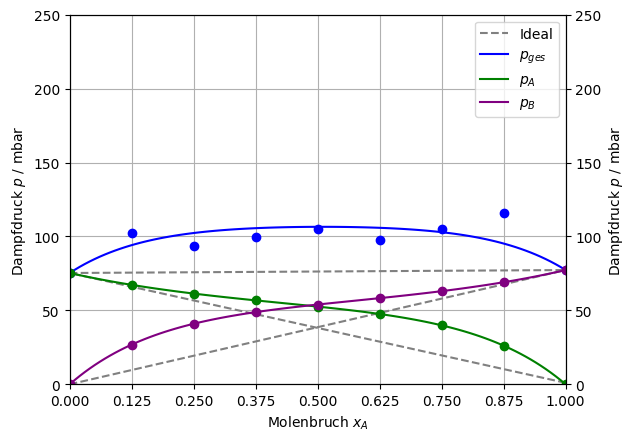

     x_A  Pressure Theory       y_A       y_B
0  0.000        75.300000  0.000000  1.000000
1  0.125        94.132528  0.285300  0.714700
2  0.250       102.343230  0.400156  0.599844
3  0.375       105.616286  0.462366  0.537634
4  0.500       106.534098  0.506553  0.493447
5  0.625       105.860986  0.550638  0.449362
6  0.750       102.914180  0.612360  0.387640
7  0.875        95.224568  0.725268  0.274732
8  1.000        77.300000  1.000000  0.000000


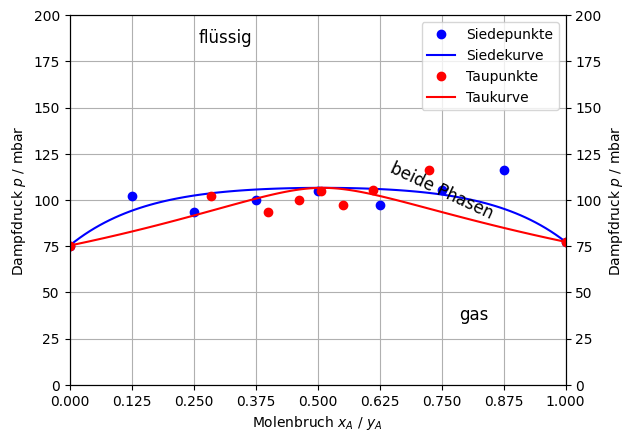

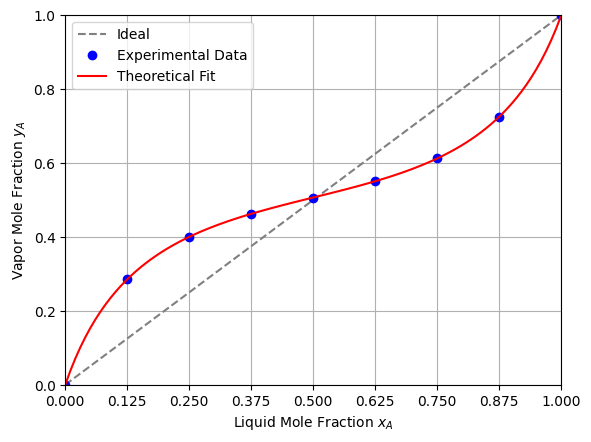

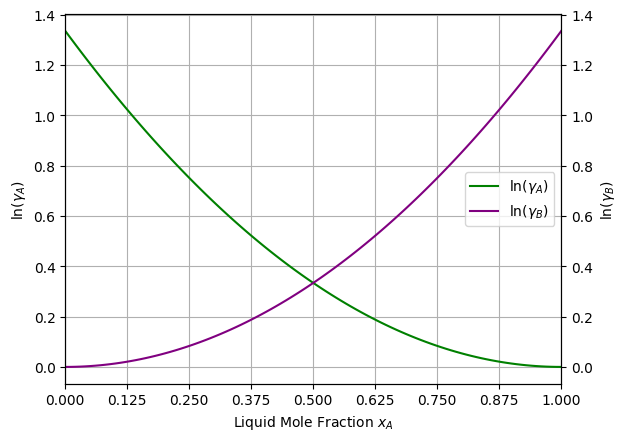

FileNotFoundError: [Errno 2] No such file or directory: 'GötschlAlexander_pVonXundTvonX.xlsx'

In [2]:
# -*- coding: utf-8 -*-
"""p(x) + T(x).ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/15r4TMQW00LA_JfdDZ9SU7a1r2QXDeBRA
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from numpy import exp

# ===============================
# Daten einlesen
# ===============================
df = pd.read_excel("Hallo.xlsx", engine="openpyxl",
                   usecols="A,H,I,J", skiprows=6, nrows=9)

df.columns = ["x_A", "p_A", "p_B", "p_ges"]
x = df["x_A"]
pA = df["p_A"]
pB = df["p_B"]
p_ges = df["p_ges"]
R = 8.314 #J/mol/K
T = 298.15 #K


# Plot
fig, ax1 = plt.subplots()


# Gemessener Dampfdruck
ax1.plot(x,p_ges, marker="o", linestyle="", color="blue")


# Idealer Dampfdruck
ax1.plot([x[0], x[8]], [p_ges[0], p_ges[8]], color="gray", linestyle="--", label="Ideal")
ax1.plot([0, x[8]], [0, p_ges[8]], color="gray", linestyle="--")
ax1.plot([1, x[0]], [1, p_ges[0]], color="gray", linestyle="--")


# Achsenbeschriftung
ax1.set_xlabel(r"Molenbruch $x_A$")
ax1.set_ylabel(r"Dampfdruck $p$ / mbar")
ax2 = ax1.twinx()
ax2.set_ylabel(r"Dampfdruck $p$ / mbar")

ax1.set_xlim(0,1)
ax1.set_ylim(0,250)
ax2.set_ylim(ax1.get_ylim())

ax1.set_xticks(np.linspace(0,1,9))


# Fit function
def fit_pges(x_data, Omega):
  return p_ges[0]*(1-x_data)*np.exp(Omega/R/T*x_data**2)+p_ges[8]*x_data*np.exp(Omega/R/T*(1-x_data)**2)

initial_guess = [100]
try:
    params, params_covariance = curve_fit(fit_pges, x, p_ges, p0=initial_guess)

    x_fit = np.linspace(0, 1, 100)
    p_fit = fit_pges(x_fit, params[0])

    # Calculate and print the error of Omega
    omega_error = np.sqrt(np.diag(params_covariance))[0]
    print(f"Omega = {params[0]:.2f} ± {omega_error:.2f} J/mol")

except RuntimeError as e:
    print(f"Error during curve fitting: {e}")
    print("Try a different initial guess for the 'O' parameter in curve_fit.")
except ValueError as e:
    print(f"Error during curve fitting: {e}")
    print("Check your data or the fit function.")

ax1.plot(x_fit, fit_pges(x_fit, params[0]), color="blue", label=r"$p_{ges}$")


# Partialdrücke mit Omega berechnet
x_values = np.linspace(0, 1, 100)
partial_pressure_A_smooth = p_ges[0] * (1 - x_values) * np.exp(params[0] / (R * T) * x_values**2)
partial_pressure_B_smooth = p_ges[8] * x_values * np.exp(params[0] / (R * T) * (1 - x_values)**2)

partial_pressure_A_original_x = p_ges[0] * (1 - x) * np.exp(params[0] / (R * T) * x**2)
partial_pressure_B_original_x = p_ges[8] * x * np.exp(params[0] / (R * T) * (1 - x)**2)

ax1.plot(x_values, partial_pressure_A_smooth, color="green", linestyle="-", label=r"$p_A$")
ax1.plot(x_values, partial_pressure_B_smooth, color="purple", linestyle="-", label=r"$p_B$")


# Partialdrücke plotten
ax1.plot(x, partial_pressure_A_original_x, marker="o", linestyle="", color="green")
ax1.plot(x, partial_pressure_B_original_x, marker="o", linestyle="", color="purple")


# Tabelle
data = {'x_A': x,
        'Partial Pressure A': partial_pressure_A_original_x,
        'Partial Pressure B': partial_pressure_B_original_x}

partial_pressure_df = pd.DataFrame(data)

print(partial_pressure_df)


ax1.legend()
ax1.grid(True)
plt.show()

# Daten
p_th = fit_pges(x, params[0])

y_th_B = partial_pressure_A_original_x / p_th # This was originally y_th_A
y_th_A = partial_pressure_B_original_x / p_th # This was originally y_th_B

data = {'x_A': x,
        'Pressure Theory': p_th,
        'y_A': y_th_A,
        'y_B': y_th_B}

theoretical_pressure_df = pd.DataFrame(data)

print(theoretical_pressure_df)


# Plot
fig, ax1 = plt.subplots()


# Siedekurve
ax1.plot(x,p_ges, marker="o", linestyle="", color="blue", label="Siedepunkte")

def fit_Siede(x_data, Omega_fit):
  return p_ges[0]*(1-x_data)*np.exp(Omega_fit/R/T*x_data**2)+p_ges[8]*x_data*np.exp(Omega_fit/R/T*(1-x_data)**2)

initial_guess = [100]
try:
    params, params_covariance = curve_fit(fit_Siede, x, p_ges, p0=initial_guess)

    x_fit = np.linspace(0, 1, 100)
    p_fit_siede = fit_Siede(x_fit, params[0])

    ax1.plot(x_fit, p_fit_siede, color="blue", linestyle="-", label="Siedekurve")

except RuntimeError as e:
    print(f"Error during curve fitting: {e}")
    print("Try a different initial guess for the 'O' parameter in curve_fit.")
except ValueError as e:
    print(f"Error during curve fitting: {e}")
    print("Check your data or the fit function.")


# Taukurve
ax1.plot(y_th_A,p_ges, marker="o", linestyle="", color="red", label="Taupunkte")


# Use a finer range of x values for smoother theoretical curves
x_smooth = np.linspace(0, 1, 100)

# Use params[0] which is the fitted Omega from this cell's curve_fit
gamma_A_smooth = np.exp(params[0] / (R * T) * (1 - x_smooth)**2)
gamma_B_smooth = np.exp(params[0] / (R * T) * x_smooth**2)


# Calculate theoretical partial pressures for smooth curve
try:
    pB_sat = p_ges[0]
    pA_sat = p_ges[8]
except NameError:
    print("Error: p_ges not found. Please ensure the data loading cell has been run successfully.")
    pA_sat = 157.1
    pB_sat = 62.2


# Corrected calculation for theoretical partial pressures
pA_calc_smooth = pA_sat * x_smooth * gamma_A_smooth
pB_calc_smooth = pB_sat * (1 - x_smooth) * gamma_B_smooth


# Calculate theoretical total pressure for smooth curve
p_total_calc_smooth = pA_calc_smooth + pB_calc_smooth

# Calculate theoretical vapor mole fractions (using the corrected calculation) for smooth curve
yA_calc_smooth = pA_calc_smooth / p_total_calc_smooth
yB_calc_smooth = pB_calc_smooth / p_total_calc_smooth


# Dew point curve (calculated) - plot yA_calc_smooth vs p_total_calc_smooth
# Sort by yA_calc_smooth to ensure the line is drawn correctly
dew_point_plot_data_smooth = pd.DataFrame({'yA_calc_smooth': yA_calc_smooth, 'p_total_calc_smooth': p_total_calc_smooth}).sort_values(by='yA_calc_smooth')
ax1.plot(dew_point_plot_data_smooth['yA_calc_smooth'], dew_point_plot_data_smooth['p_total_calc_smooth'], color="red", linestyle="-", label="Taukurve")


# Phasenbeschriftung
ax1.text(0.315, 185, 'flüssig', fontsize=12, ha='center')
ax1.text(0.815, 35, 'gas', fontsize=12, ha='center')
ax1.text(0.75, 90, 'beide Phasen', fontsize=12, ha='center', rotation=335)


# Achsenbeschriftung
ax1.set_xlabel(r"Molenbruch $x_A$ / $y_A$")
ax1.set_ylabel(r"Dampfdruck $p$ / mbar")
ax2 = ax1.twinx()
ax2.set_ylabel(r"Dampfdruck $p$ / mbar")
ax1.set_xticks(np.linspace(0,1,9))


ax1.set_xlim(0, 1)
ax1.set_ylim(0, 200)
ax2.set_ylim(ax1.get_ylim())
ax1.grid(True)
ax1.legend()
plt.show()

# Plot
fig, ax = plt.subplots()

# Ideal line (y=x)
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Ideal")

# Experimental data points for y_A vs x_A
ax.plot(x, y_th_A, marker="o", linestyle="", color="blue", label="Experimental Data")

# Theoretical curve for y_A vs x_A using the fitted Omega
# We need the calculated yA_calc_smooth from the previous cell (FitRxS6jlsVn)
# Assuming yA_calc_smooth and x_smooth are available from the execution of the previous cell
try:
    ax.plot(x_smooth, yA_calc_smooth, linestyle="-", color="red", label="Theoretical Fit")
except NameError:
    print("Error: x_smooth or yA_calc_smooth not found. Please ensure the previous cell (FitRxS6jlsVn) has been run successfully.")


ax.set_xlabel(r"Liquid Mole Fraction $x_A$")
ax.set_ylabel(r"Vapor Mole Fraction $y_A$")
ax.set_xticks(np.linspace(0,1,9))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1) # y_A ranges from 0 to 1


ax.grid(True)
ax.legend() # Add legend
plt.show()

# Calculate activity coefficients using the fitted Omega from the previous cell (FitRxS6jlsVn)
# Assuming params[0] (the fitted Omega), R, and T are available from previous cell execution

try:
    Omega = params[0]
    R = 8.314 # J/mol/K
    T = 298.15 # K

    # Use a finer range of x values for a smooth curve
    x_smooth = np.linspace(0, 1, 100)

    gamma_A_calc = np.exp(Omega / (R * T) * (1 - x_smooth)**2)
    gamma_B_calc = np.exp(Omega / (R * T) * x_smooth**2)

    # Calculate the natural logarithm of the activity coefficients
    ln_gamma_A = np.log(gamma_A_calc)
    ln_gamma_B = np.log(gamma_B_calc)


    # Plot natural logarithm of activity coefficients
    fig, ax1 = plt.subplots()

    ax1.plot(x_smooth, ln_gamma_A, linestyle="-", color="green", label=r"$\ln(\gamma_A)$")
    ax1.plot(x_smooth, ln_gamma_B, linestyle="-", color="purple", label=r"$\ln(\gamma_B)$")

except NameError:
    print("Error: params, R, or T not found. Please ensure the curve fitting cell (FitRxS6jlsVn) has been run successfully.")
except Exception as e:
    print(f"An error occurred: {e}")


ax1.set_xlabel(r"Liquid Mole Fraction $x_A$")
ax1.set_ylabel(r"ln($\gamma_A$)")
ax1.set_xlim(0, 1)
ax2 = ax1.twinx()
ax2.set_ylabel(r"ln($\gamma_B$)")
ax2.set_ylim(ax1.get_ylim())

ax1.set_xticks(np.linspace(0,1,9))

ax1.grid(True)
ax1.legend()
plt.show()

# Daten
df = pd.read_excel('GötschlAlexander_pVonXundTvonX.xlsx', engine="openpyxl",usecols="K,L,N", skiprows=6, nrows=9)

df.columns = ["F_A", "F_B", "T_SD"]
F_A = df["F_A"]
F_B = df["F_B"]
T_SD = df["T_SD"]

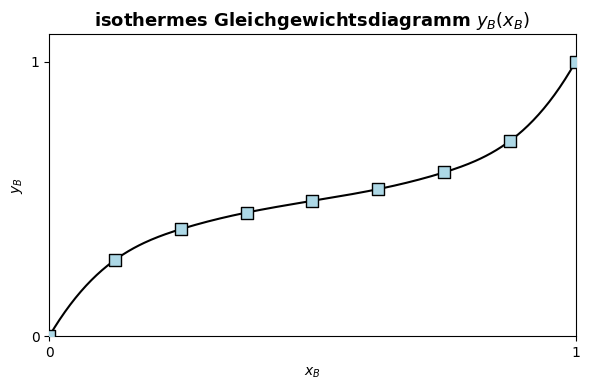

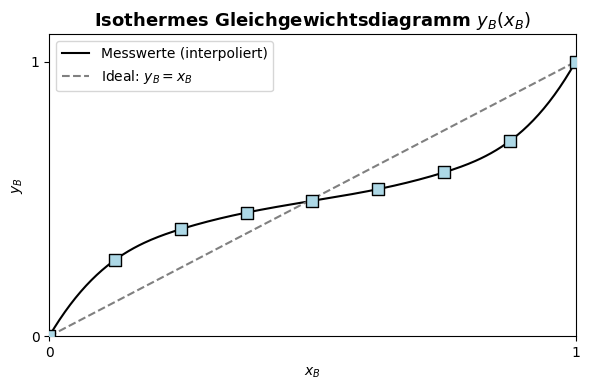

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# ===============================
# Daten einlesen
# ===============================
df = pd.read_excel("Exp2-3_Claire.xlsx", engine="openpyxl",
                   usecols="A,H", skiprows=6, nrows=9)
df.columns = ["x_A", "y_B"]
df["x_B"] = 1 - df["x_A"]

# ===============================
# Glatte Kurve fitten
# ===============================
# Nach x_B sortieren
df_sorted = df.sort_values("x_B")
x = df_sorted["x_B"].to_numpy()
y = df_sorted["y_B"].to_numpy()

# Glatter Verlauf per Spline
x_smooth = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=3)
y_smooth = spline(x_smooth)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(6, 4))

# Glatte Linie
plt.plot(x_smooth, y_smooth, color='black')

# Punkte wie im Bild
plt.scatter(x, y, color='lightblue', edgecolor='black', s=80, marker='s', zorder=3)

# Achsen-Design
plt.xlabel("$x_B$")
plt.ylabel("$y_B$")
plt.title("isothermes Gleichgewichtsdiagramm $y_B(x_B)$", fontsize=13, fontweight="bold")
plt.grid(False)
plt.xlim(0, 1)
plt.ylim(0, 1.1)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.tight_layout()
plt.show()

# ===============================
# Plot
# ===============================
plt.figure(figsize=(6, 4))

# Glatte Gleichgewichtskurve
plt.plot(x_smooth, y_smooth, color='black', label="Messwerte (interpoliert)")

# Idealverhalten: y_B = x_B
plt.plot(x_smooth, x_smooth, linestyle='--', color='gray', label='Ideal: $y_B = x_B$')

# Messpunkte
plt.scatter(x, y, color='lightblue', edgecolor='black', s=80, marker='s', zorder=3)

# Achsen-Design
plt.xlabel("$x_B$")
plt.ylabel("$y_B$")
plt.title("Isothermes Gleichgewichtsdiagramm $y_B(x_B)$", fontsize=13, fontweight="bold")
plt.grid(False)
plt.xlim(0, 1)
plt.ylim(0, 1.1)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.legend()
plt.tight_layout()
plt.show()

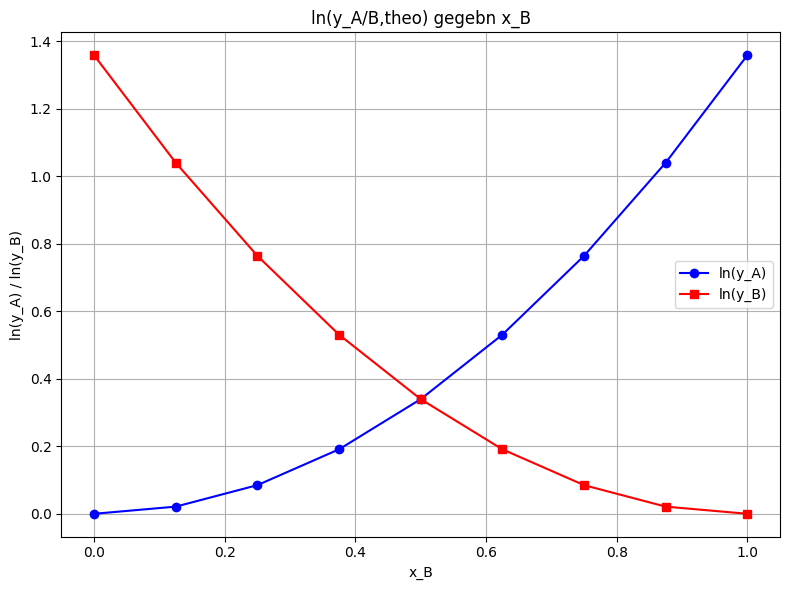

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Daten einlesen
# ===============================
df = pd.read_excel("Exp2-3_Claire.xlsx", engine="openpyxl",
                   usecols="B,C,D", skiprows=21, nrows=9)
df.columns = ["ln(y_B)", "x_B", "ln(y_A)"]

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(8, 6))

# ln(y_A) vs. x_B
plt.plot(df["x_B"], df["ln(y_A)"], marker='o', color='blue', label='ln(y_A)')

# ln(y_B) vs. x_B
plt.plot(df["x_B"], df["ln(y_B)"], marker='s', color='red', label='ln(y_B)')

# Achsen & Layout
plt.xlabel("x_B")
plt.ylabel("ln(y_A) / ln(y_B)")
plt.title("ln(y_A/B,theo) gegebn x_B")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
print(df.head(9))

    ln(y_B)    x_B   ln(y_A)
0  0.000000  1.000  1.357941
1  0.021218  0.875  1.039673
2  0.084871  0.750  0.763842
3  0.190960  0.625  0.530446
4  0.339485  0.500  0.339485
5  0.530446  0.375  0.190960
6  0.763842  0.250  0.084871
7  1.039673  0.125  0.021218
8  1.357941  0.000  0.000000


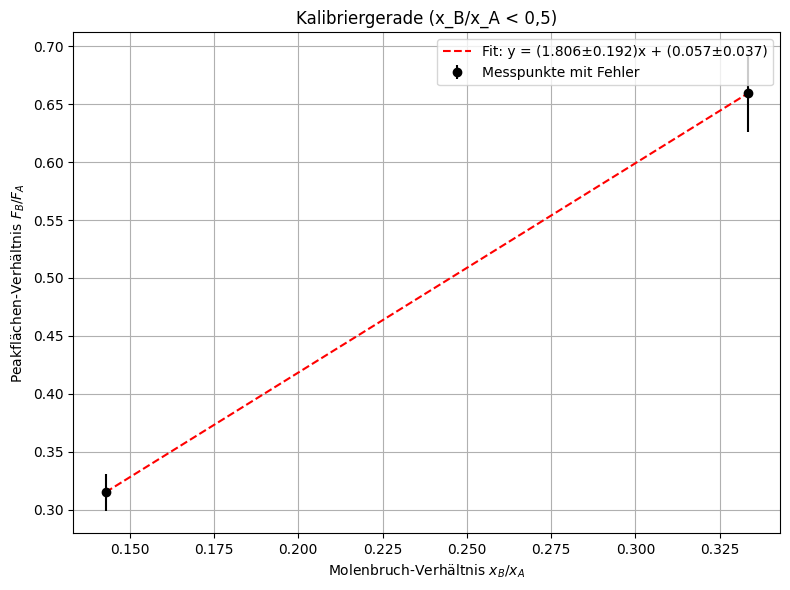

--- Bereich: x_B/x_A < 0,5 ---
Steigung m = 1.8061 ± 0.1918
y-Achsenabschnitt b = 0.0572 ± 0.0370



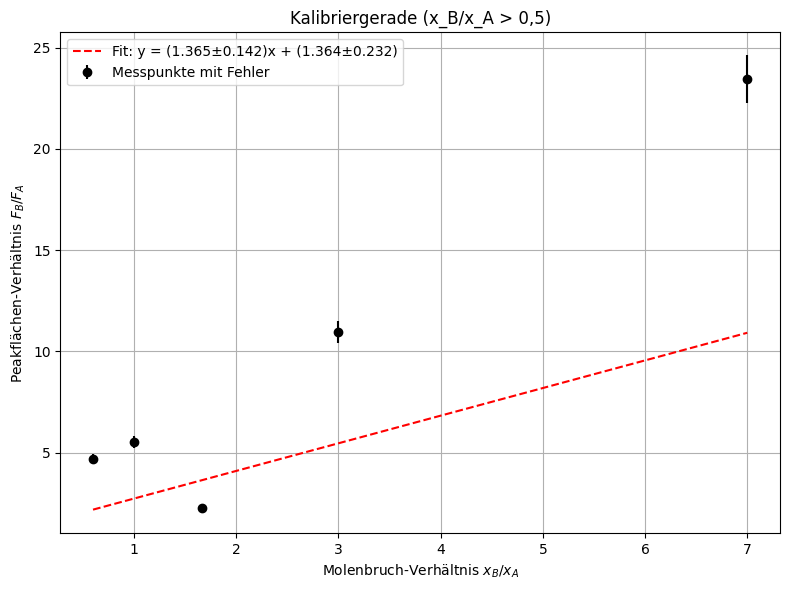

--- Bereich: x_B/x_A > 0,5 ---
Steigung m = 1.3650 ± 0.1419
y-Achsenabschnitt b = 1.3645 ± 0.2317



In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ===============================
# Excel-Daten einlesen
# ===============================
df = pd.read_excel("Hallo.xlsx",
                   engine="openpyxl",
                   usecols="N,O",
                   skiprows=46,
                   nrows=10)

df.columns = ["x_ratio", "F_ratio"]
df["F_ratio_err"] = df["F_ratio"] * 0.05

# ===============================
# Funktion für Plot und Fit
# ===============================
def fit_and_plot(df_section, title_suffix):
    x = df_section["x_ratio"].values
    y = df_section["F_ratio"].values
    y_err = df_section["F_ratio_err"].values

    # Lineare Funktion
    def lin_func(x, m, b):
        return m * x + b

    # Fit
    popt, pcov = curve_fit(lin_func, x, y, sigma=y_err, absolute_sigma=True)
    m, b = popt
    m_err, b_err = np.sqrt(np.diag(pcov))

    # Fit-Kurve
    x_fit = np.linspace(min(x), max(x), 200)
    y_fit = lin_func(x_fit, m, b)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.errorbar(x, y, yerr=y_err, fmt='o', color='black', label="Messpunkte mit Fehler")
    plt.plot(x_fit, y_fit, 'r--',
             label=f"Fit: y = ({m:.3f}±{m_err:.3f})x + ({b:.3f}±{b_err:.3f})")

    plt.xlabel(r"Molenbruch-Verhältnis $x_B/x_A$")
    plt.ylabel(r"Peakflächen-Verhältnis $F_B/F_A$")
    plt.title(f"Kalibriergerade ({title_suffix})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Ausgabe
    print(f"--- Bereich: {title_suffix} ---")
    print(f"Steigung m = {m:.4f} ± {m_err:.4f}")
    print(f"y-Achsenabschnitt b = {b:.4f} ± {b_err:.4f}")
    print()

# ===============================
# Daten aufteilen und Plotten
# ===============================
df_low = df[df["x_ratio"] < 0.5]
df_high = df[df["x_ratio"] > 0.5]

fit_and_plot(df_low, "x_B/x_A < 0,5")
fit_and_plot(df_high, "x_B/x_A > 0,5")

   x_B  T_bp  y_B
7  NaN   NaN  NaN


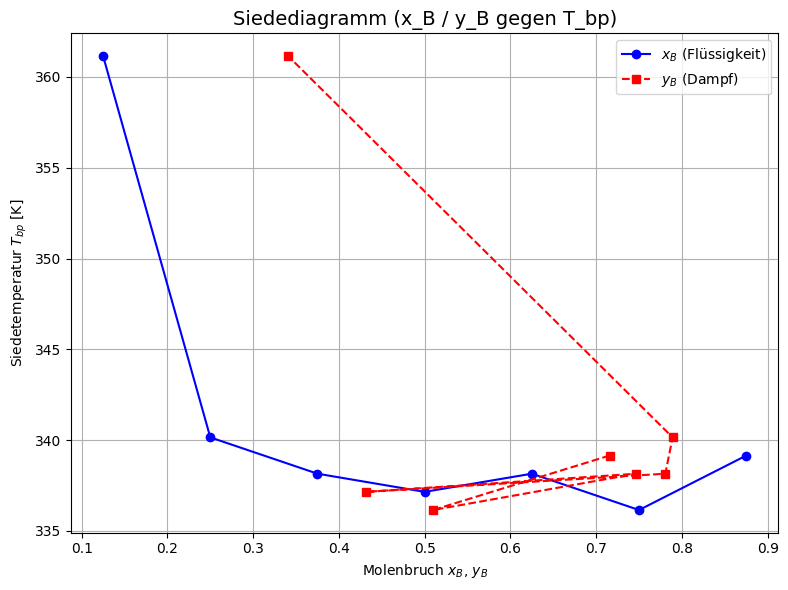

     x_B    T_bp       y_B
0  0.875  339.15  0.715698
1  0.750  336.15  0.509679
2  0.625  338.15  0.747013
3  0.500  337.15  0.431998
4  0.375  338.15  0.780647


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Daten einlesen
df = pd.read_excel("Hallo.xlsx",
                   engine="openpyxl",
                   usecols="C, F, H", skiprows=36, nrows=9)
df.columns = ["x_B", "T_bp", "y_B"]

# Konvertiere alle relevanten Spalten zu float (falls irgendwo Text wie 'yA vap' steht)
df["x_B"] = pd.to_numeric(df["x_B"], errors="coerce")
df["y_B"] = pd.to_numeric(df["y_B"], errors="coerce")
df["T_bp"] = pd.to_numeric(df["T_bp"], errors="coerce")

# Optional: Zeige Zeilen mit NaN (also ungültigen Werten)
print(df[df.isna().any(axis=1)])

# Plot
plt.figure(figsize=(8, 6))

# Siedetemperatur gegen Molenbrüche in Flüssigkeit und Gas
plt.plot(df["x_B"], df["T_bp"], marker='o', linestyle='-', color='blue', label=r'$x_B$ (Flüssigkeit)')
plt.plot(df["y_B"], df["T_bp"], marker='s', linestyle='--', color='red', label=r'$y_B$ (Dampf)')

# Achsen und Layout
plt.xlabel("Molenbruch $x_B$, $y_B$")
plt.ylabel("Siedetemperatur $T_{bp}$ [K]")
plt.title("Siedediagramm (x_B / y_B gegen T_bp)", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(df.head())

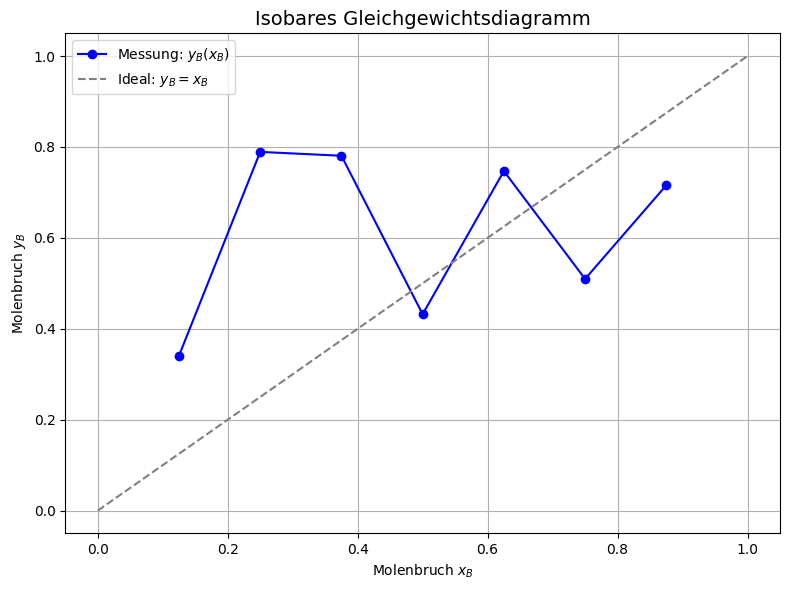

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Daten einlesen
df = pd.read_excel("Hallo.xlsx",
                   engine="openpyxl",
                   usecols="C,H", skiprows=36, nrows=9)
df.columns = ["x_B", "y_B"]

# Plot
plt.figure(figsize=(8, 6))

# Messkurve: y_B gegen x_B
plt.plot(df["x_B"], df["y_B"], marker='o', linestyle='-', color='blue', label=r'Messung: $y_B(x_B)$')

# Idealverhalten: y_B = x_B
x_ideal = np.linspace(0, 1, 100)
plt.plot(x_ideal, x_ideal, linestyle='--', color='gray', label='Ideal: $y_B = x_B$')

# Achsen & Layout
plt.xlabel("Molenbruch $x_B$")
plt.ylabel("Molenbruch $y_B$")
plt.title("Isobares Gleichgewichtsdiagramm", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()